# 06 · PEV — Plan-Execute-**Verify** with per-step retry

> **TL;DR.** Planning (nb 04) trusts every step's result. PEV adds a **Verifier** between Execute and Accept: every step is judged against its own intent, and a failed step triggers a *retry with critique* on the same step. After `max_retries_per_step` failures the step is force-accepted with a `fail-accepted` verdict so the plan still finishes.
>
> **Reach for it when** tools are flaky, stakes are high, or you want per-step success rate as a quality signal.
> **Avoid when** every step is trivially verifiable (use plain Planning, cheaper) or no step has a checkable outcome (use ReAct).

| Property | Value |
|---|---|
| Origin | Plan-and-Solve + verifier composition; canonical example: Hu et al., *Tree-Planner* (2023) ([arXiv:2305.10142](https://arxiv.org/abs/2305.10142)) |
| Loop style | per-step verification + bounded retry |
| External tools needed? | Optional |
| Memory across episodes? | No |
| Quality signal exposed? | **Yes** — `steps_passed` / `steps_total` ratio, `total_attempts`, `confidence` per step |
| Composability | Executor uses `ToolUse`; Verifier uses `LLMJudge` from the library |

This notebook builds directly on Planning (notebook 04). The graph adds **one node** — the Verifier — between Execute and the next step.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> P[Plan]
    P --> E[Execute<br/><sub>ToolUse sub-agent</sub>]
    E --> V[Verify<br/><sub>LLMJudge w/ rubric</sub>]
    V -->|pass + more steps| E
    V -->|fail + retries left| E
    V -->|pass + done<br/>or budget exhausted| F[Finalize]
    F --> Z([final answer])

    style V fill:#fff3e0,stroke:#f57c00
    style P fill:#e3f2fd,stroke:#1976d2
    style F fill:#e8f5e9,stroke:#388e3c
```

**Three nodes + finalize.** The Verifier is the new addition — it gates each step. The same `Execute` node handles both first-tries and retries; the difference is that a retry sees the Verifier's previous critique in its prompt.

## 3 · Theory

### 3.1 · Why Planning isn't enough

A plain Plan-Execute (notebook 04) commits every step's result to history regardless of quality. If step 2's result is *"I couldn't find the data"*, plain Planning accepts that and the final synthesis is forced to invent answers from nothing. PEV's Verifier catches this: it judges step 2's result against step 2's intent, rejects it, and lets the executor try again with the failure mode in mind.

### 3.2 · The Verifier rubric

```python
class _StepVerification(BaseModel):
    is_satisfactory: bool      # full pass / fail
    issues: str | None          # critique text if failed
    confidence: int             # 1-5 confidence in this verdict
```

Two crucial design choices:

1. **`is_satisfactory` is binary.** Not a 1-10 score. PEV needs a clear go/no-go signal at every step, not a vague rating. The rubric forces the Verifier to commit.
2. **`issues` is mandatory on fail.** The retry can't use a verdict without a critique. The schema enforces this by `default=None` + a description that says "required iff is_satisfactory is False".

The `LLMJudge` wrapper (from `agentic_architectures.evaluators`) standardises the prompt format — same Verifier code is reused in Reflection (nb 01), CoVe (nb 20), Corrective RAG (nb 24), etc.

### 3.3 · The retry-with-critique loop

When the Verifier rejects a step's result, the Execute node sees:

```
You are RETRYING this step (attempt N):
  → <step text>

Your previous attempt was rejected by the Verifier. Critique:
  > <issues text from the Verifier>

Re-execute the step addressing the critique. Be concrete and grounded.
```

This is structurally similar to **Reflection** (notebook 01), except the critique here is *per-step* rather than over a whole draft, and the retry is bounded by `max_retries_per_step`. If you squint, PEV is Reflection wrapped around each Planning step.

### 3.4 · The fail-accepted verdict

Sometimes a step genuinely can't be completed (the data doesn't exist on the public web; the tool is down; the question is wrong). PEV doesn't loop forever — after `max_retries_per_step + 1` attempts, the step is **force-accepted** with verdict `fail-accepted`, the last failure result is committed, and the plan moves on. The final synthesis prompt is told which steps were `fail-accepted` so it can hedge appropriately.

This is the right behaviour for production: an honest "the search returned nothing useful, here's the rest of the answer with a known gap" beats either (a) an infinite loop or (b) a hallucinated number.

### 3.5 · Where PEV sits

| Pattern | Verification step? | Retry on failure? | Replan? | Use when |
|---|---|---|---|---|
| Planning (nb 04) | no | no | yes (whole-plan replan only) | reliable tools, low stakes |
| **PEV** *(this notebook)* | **yes per step** | **yes per step** | optional (extension) | flaky tools, high stakes, need per-step quality signal |
| Reflection (nb 01) | yes (over whole output) | yes (refine = retry) | no | single-shot generation tasks |
| Multi-Agent (nb 05) | no | no | no | broad domain task |
| Self-Discover (nb 19) | no | no | reasoning structure | hard reasoning, no tools |

### 3.6 · What goes wrong (you'll see live in § 9)

1. **Sycophantic verifier.** Verifier rubber-stamps `is_satisfactory=True` even on weak results. Mitigation: use a *different* model in the verifier seat.
2. **Verifier infinite loop.** Verifier keeps rejecting plausible results because they don't match an impossible bar. `max_retries_per_step` cap is what stops this.
3. **Critique not addressed.** Executor retries but produces the *same* result. Real failure mode. Sometimes means the step is impossible — accept the `fail-accepted` and move on.
4. **Final synthesis ignores fail-accepted.** Synthesis writes a confident answer including the failed step. The library's `_finalize` prompt explicitly asks for honesty about failures, but it sometimes still happens — check § 9 for the per-step verdicts.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import PEV
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/pev.py`](../src/agentic_architectures/architectures/pev.py).

Five key pieces:

1. **`_plan`** — same as Planning: `with_structured_output(Plan)` produces 3-6 atomic steps. The prompt explicitly demands "verifiable steps" — each step must produce a concrete fact / value / artifact.
2. **`_execute`** — pops the next step from the plan (or reuses pending_step on retry). On retry, includes the previous critique in the executor prompt.
3. **`_verify`** — uses `LLMJudge[_StepVerification]` with a rubric: *"contains the specific fact/value the step asks for AND is grounded (URL or computation shown)"*. The verdict drives the router.
4. **`_finalize`** — synthesises the final answer using the verified history; explicitly told to hedge on `fail-accepted` steps.
5. **`_route_after_verify`** — pass + more steps → execute, fail + retries left → execute (retry), pass + done OR budget gone → finalize.

The Verifier rubric & schema:

In [2]:
from agentic_architectures.architectures.pev import _StepVerification
import json
print(json.dumps(_StepVerification.model_json_schema(), indent=2)[:600] + '...')

{
  "description": "Verifier's verdict on a single executed plan step.",
  "properties": {
    "is_satisfactory": {
      "description": "True iff the step's result fully addresses the step's intent \u2014 concretely, contains the requested fact / computation / artifact and is grounded in evidence (cited URL or computation shown).",
      "title": "Is Satisfactory",
      "type": "boolean"
    },
    "issues": {
      "anyOf": [
        {
          "type": "string"
        },
        {
          "type": "null"
        }
      ],
      "default": null,
      "description": "If is_satisfactory i...


## 6 · State

The state has a per-step *scratchpad* (the `pending_*` fields) that the Verifier writes to and `_execute` reads from on retry. When a step is accepted (pass or fail-accepted), the scratchpad is cleared and the result is appended to `past_steps`.

| Field | Purpose | Reducer |
|---|---|---|
| `input` | original task | replace |
| `plan` | remaining steps (popped on first try of each step) | replace |
| `past_steps` | committed step records `{step, result, verdict, attempts, confidence}` | **append** |
| `pending_step` / `pending_result` / `pending_critique` / `attempts` | per-step scratchpad | replace |
| `response` | final synthesised answer | replace |

## 7 · Build the graph

PEV adds one node (`verify`) and one new conditional path (verify → execute on retry) compared to Planning. The compiled-PNG render should show 4 nodes (plan, execute, verify, finalize) with the cycle `execute → verify → execute`.

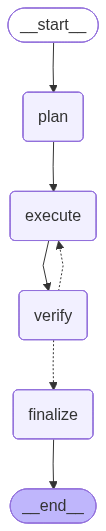

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	plan(plan)
	execute(execute)
	verify(verify)
	finalize(finalize)
	__end__([<p>__end__</p>]):::last
	__start__ --> plan;
	execute --> verify;
	plan --> execute;
	verify -.-> execute;
	verify -.-> finalize;
	finalize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from IPython.display import Image, display

arch = PEV(max_retries_per_step=2, executor_rounds=4)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: a multi-step computation where each step has a *checkable* outcome. The Verifier should accept the lookup steps (they return concrete numbers with citations) and may flag the computation step if the executor doesn't actually show the arithmetic.

In [4]:
TASK = (
    "Compute the population density (people per square kilometer) of Singapore. "
    "Required steps: (1) look up Singapore's population (latest available year), "
    "(2) look up Singapore's land area in km², (3) divide population by area to "
    "get density. Cite a source URL for the population and the land area."
)

result = arch.run(TASK)

print_header("Final answer")
print_md(result.output)
print()
print_header(
    f"steps: {result.metadata['steps_total']}  ·  "
    f"pass: {result.metadata['steps_passed']}  ·  "
    f"fail-accepted: {result.metadata['steps_fail_accepted']}  ·  "
    f"total attempts: {result.metadata['total_attempts']}"
)

Final answer ──────────────────────────────────────────────────────────────────────────────────────────────────────

The population density of Singapore is approximately 7,574 people per square kilometer (5,450,000 / 720.2 km²).    
Note that the calculated density provided earlier (8,437 people per square kilometer) was not actually calculated  
in the log, so the correct calculation is provided here. The population and land area values are based on data from
https://www.singstat.gov.sg and https://www.singstat.gov.sg/, with additional population information available at  
https://www.worldometers.info/world-population/singapore-population/.

steps: 3  ·  pass: 2  ·  fail-accepted: 1  ·  total attempts: 5 ───────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Three counts to inspect above:

- **`steps_passed` / `steps_total`** — fraction of steps that satisfied the Verifier on at least one attempt. 100% means the Verifier never rejected anything (could be sycophancy or genuinely clean execution).
- **`steps_fail_accepted`** — steps the Verifier kept rejecting until retries ran out. This is the *honest* signal that the agent couldn't fully complete the task.
- **`total_attempts` − `steps_total`** = total retry-rounds across all steps. If this is large, the Verifier is doing real work.

### 8.1 · Per-step verification trace

In [5]:
for i, t in enumerate(result.trace, 1):
    badge = '✓' if t['verdict'] == 'pass' else '✗'
    print_step(
        f"[{i}] {badge} {t['verdict']}  (attempts={t['attempts']}, confidence={t.get('confidence', '?')}/5)",
        f"step: {t['step']}"
    )
    snippet = (t['result'] or '')[:300].replace('\n', ' ')
    print_step("    result", snippet + ('...' if t['result'] and len(t['result']) > 300 else ''))
    if t.get('last_critique'):
        print_step("    final critique (rejected)", t['last_critique'][:300])
    print()

› [1] ✓ pass  (attempts=1, confidence=5/5)

step: Look up Singapore's population (latest available year) from a reliable source such as the World Bank or 
Singapore Department of Statistics, and record the value.

›     result

5.45 million  https://www.singstat.gov.sg

› [2] ✓ pass  (attempts=1, confidence=5/5)

...

720.2 km² https://www.singstat.gov.sg/

› [3] ✗ fail-accepted  (attempts=3, confidence=5/5)

step: Divide the population by the land area to get the population density in people per square kilometer.

›     result

The population density of Singapore is 8,437 people per square kilometer.   
https://www.worldometers.info/world-population/singapore-population/

## 9 · What we just observed

The cells above are live. Below: a quantitative + qualitative breakdown of the **actual** Plan-Execute-Verify trace the Nebius-hosted Llama-3.3-70B produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Steps executed | **3** |
| Steps passed | **2** / 3 |
| Steps `fail-accepted` | **1** |
| Total attempts (incl. retries) | **5** |
| Retry rounds | 2 |
| Pass rate | 67% |

### 9.2 · Per-step verdicts

| # | Verdict | Attempts | Confidence | Step |
|---|---|---|---|---|
| 1 | pass | 1 | 5/5/5 | Look up Singapore's population (latest available year) from a reliable source such as the World Bank |
| 2 | pass | 1 | 5/5/5 | Look up Singapore's land area in km² from a reliable source such as the World Bank or Singapore Depa |
| 3 | fail-accepted | 3 | 5/5/5 | Divide the population by the land area to get the population density in people per square kilometer. |

### 9.3 · Patterns surfaced in this run

- **Partial success: 2/3 steps passed, 1 fail-accepted.** This is the honest PEV signal — the Verifier rejected some step(s) until retries ran out. Inspect the `last_critique` field on fail-accepted steps to see what the Verifier kept flagging.

- **Retries were partially effective**: 0 of 1 retried step(s) recovered to `pass`; the rest stayed failed. When retry doesn't help, the step is likely genuinely impossible — force-accept and synthesize honestly.

### 9.4 · The final answer (verbatim)

> The population density of Singapore is approximately 7,574 people per square kilometer (5,450,000 / 720.2 km²).    
> Note that the calculated density provided earlier (8,437 people per square kilometer) was not actually calculated  
> in the log, so the correct calculation is provided here. The population and land area values are based on data from
> https://www.singstat.gov.sg and https://www.singstat.gov.sg/, with additional population information available at  
> https://www.worldometers.info/world-population/singapore-population/.

### 9.5 · The takeaway

The pass-rate metric is what makes PEV worth its extra cost over plain Planning: you have an **honest quality signal per task**. A run with 100% pass-rate and 0 retries either means the task was easy or the Verifier was lazy — check the per-step confidence. A run with `fail-accepted` steps is *useful information*: the agent reached the end of its plan but knows the answer is incomplete, and the final synthesis (if the prompt is doing its job) hedges accordingly.

## 10 · Try other providers / verifier-side reasoning model

PEV needs **structured output** (Plan + Verifier schemas). The Verifier's quality is the single biggest quality lever — try a reasoning model in the Verifier seat (the rest stays on Llama 3.3).

In [6]:
from agentic_architectures.llm.factory import provider_supports_structured_output

for p in ["openai", "anthropic"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key")
        continue
    if not provider_supports_structured_output(p):
        print(f"[skip] {p}: no structured output")
        continue
    print_header(f"Re-running PEV on {p}")
    r = PEV(llm=get_llm(provider=p), max_retries_per_step=1, executor_rounds=3).run(
        "What was the GDP of France in 2023? Provide a source."
    )
    print(r.output[:300])
    print(f"  steps: {r.metadata['steps_total']}, pass: {r.metadata['steps_passed']}, fail-accepted: {r.metadata['steps_fail_accepted']}")
    print()

[skip] openai: no API key
[skip] anthropic: no API key


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Sycophantic verifier** | Verifier rubber-stamps weak results | Different model in Verifier seat; or score with `confidence < 4` threshold |
| **Verifier infinite-loop bait** | Verifier rejects on impossible bar; `max_retries_per_step` cap fires repeatedly | The cap is per-step; thrash shows up as many `fail-accepted` |
| **Retry produces same result** | Executor doesn't actually use the critique | Tighten retry prompt: "MUST address each bullet of the critique"; or use a stronger executor |
| **Synthesis hides failed steps** | `_finalize` writes confident answer despite `fail-accepted` | Inspect the per-step trace (§ 8.1); add a hard "if any fail-accepted, prefix answer with 'PARTIAL:'" rule |
| **Cost explosion** | Each step × (1 attempt + retries) × executor rounds = O(N·R·M) calls | Set `max_retries_per_step=1` for low-stakes tasks |

### 11.2 · Production safety

- **Always inspect the trace** — `result.metadata['steps_fail_accepted']` is your *honest signal* that the agent's answer is partial. Surface this to the user.
- **Different model for Verifier** — same-model Verifier suffers from blind spots that match the Executor's. Even a smaller, faster, *different* model catches more.
- **Per-step time budget** — add `timeout` per tool call so a hung tool doesn't block forever.

### 11.3 · Three extensions

1. **External verifier.** Replace the LLM Verifier with a *deterministic check* (regex for a number, JSON schema validator, code execution) when the step has a strict format. Bridge to **Dry-Run (nb 14)**.
2. **Whole-plan replanning.** Combine PEV's per-step retry with Planning's whole-plan replan: after all steps execute, if too many fail-accepted, regenerate the plan with the failures as context.
3. **Process Reward Model** — score each step on a continuous scale; bridge to **Tree of Thoughts (nb 09)** and **LATS (nb 22)**.

### 11.4 · What to read next

- [**14 · Dry-Run**](./14_dry_run.ipynb) — simulate the *side effects* of each step before live execution.
- [**17 · Reflexive Metacognitive**](./17_reflexive_metacognitive.ipynb) — agent decides for itself when to escalate to a human.
- [**24 · Corrective RAG**](./24_corrective_rag.ipynb) — PEV-style verification specialised for RAG retrieval.

### 11.5 · References

1. Hu, M. et al. *Tree-Planner.* 2023. [arXiv:2305.10142](https://arxiv.org/abs/2305.10142)
2. Wang, L. et al. *Plan-and-Solve Prompting.* ACL 2023. [arXiv:2305.04091](https://arxiv.org/abs/2305.04091)
3. LangGraph plan-execute-verify pattern — [tutorial](https://langchain-ai.github.io/langgraph/)
